## Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

## Load the cleaned dataset

In [4]:
df = pd.read_csv("../data/processed/cleaned_encoded_job_change_data.csv")
df.head()

,city_development_index,experience,last_new_job,training_hours,target,city_city_10,city_city_100,city_city_101,city_city_102,city_city_103,...,company_size_500-999,company_size_5000-9999,company_size_<10,company_size_nan,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_nan
0,0.920,21.0,1.0,36,1.0,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,0.776,15.0,5.0,47,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0.624,5.0,0.0,83,0.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,0.789,0.0,0.0,52,1.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.767,21.0,4.0,8,0.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (19158, 159)


## Separate features and target

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

In [9]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (19158, 158)
Target shape: (19158,)


## Check target distribution

In [10]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

target
0.0    14381
1.0     4777
Name: count, dtype: int64
target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64


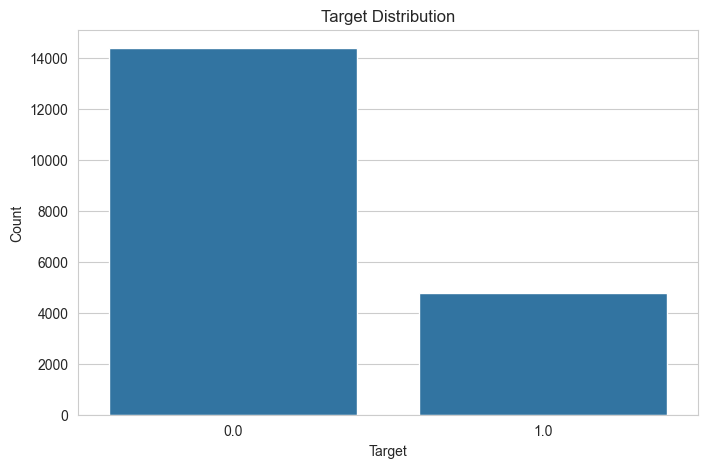

In [11]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

## Train-test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15326, 158)
X_test shape: (3832, 158)
y_train shape: (15326,)
y_test shape: (3832,)


## Train the baseline Decision Tree model

In [14]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## Make predictions

In [15]:
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

## Evaluate the baseline model

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.7203
Precision: 0.4391
Recall   : 0.4419
F1-score : 0.4405
ROC-AUC  : 0.6279


## Classification report

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.81      0.81      0.81      2877
         1.0       0.44      0.44      0.44       955

    accuracy                           0.72      3832
   macro avg       0.63      0.63      0.63      3832
weighted avg       0.72      0.72      0.72      3832



## Confusion matrix

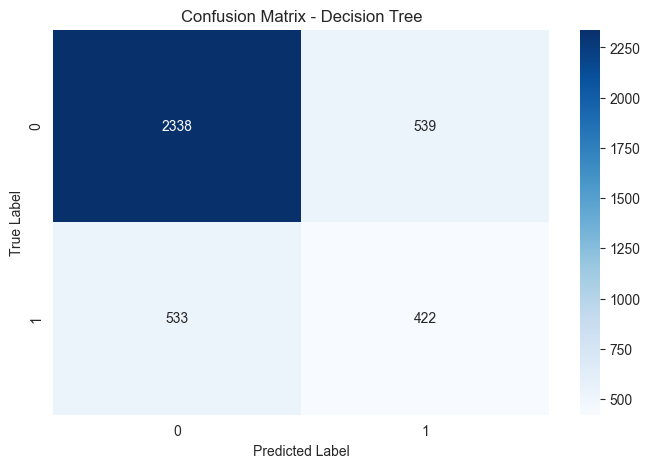

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## ROC curve

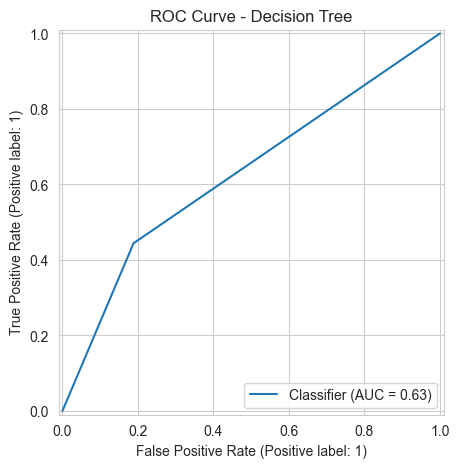

In [19]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Decision Tree")
plt.show()

## Cross-validation score

In [20]:
cv_scores = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.43500317 0.44971172 0.41792929 0.45947671 0.4520202 ]
Mean CV F1 score: 0.4428282191728926


## Check tree depth and number of leaves

In [21]:
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Tree depth: 46
Number of leaves: 3474


## Plot a simplified tree view

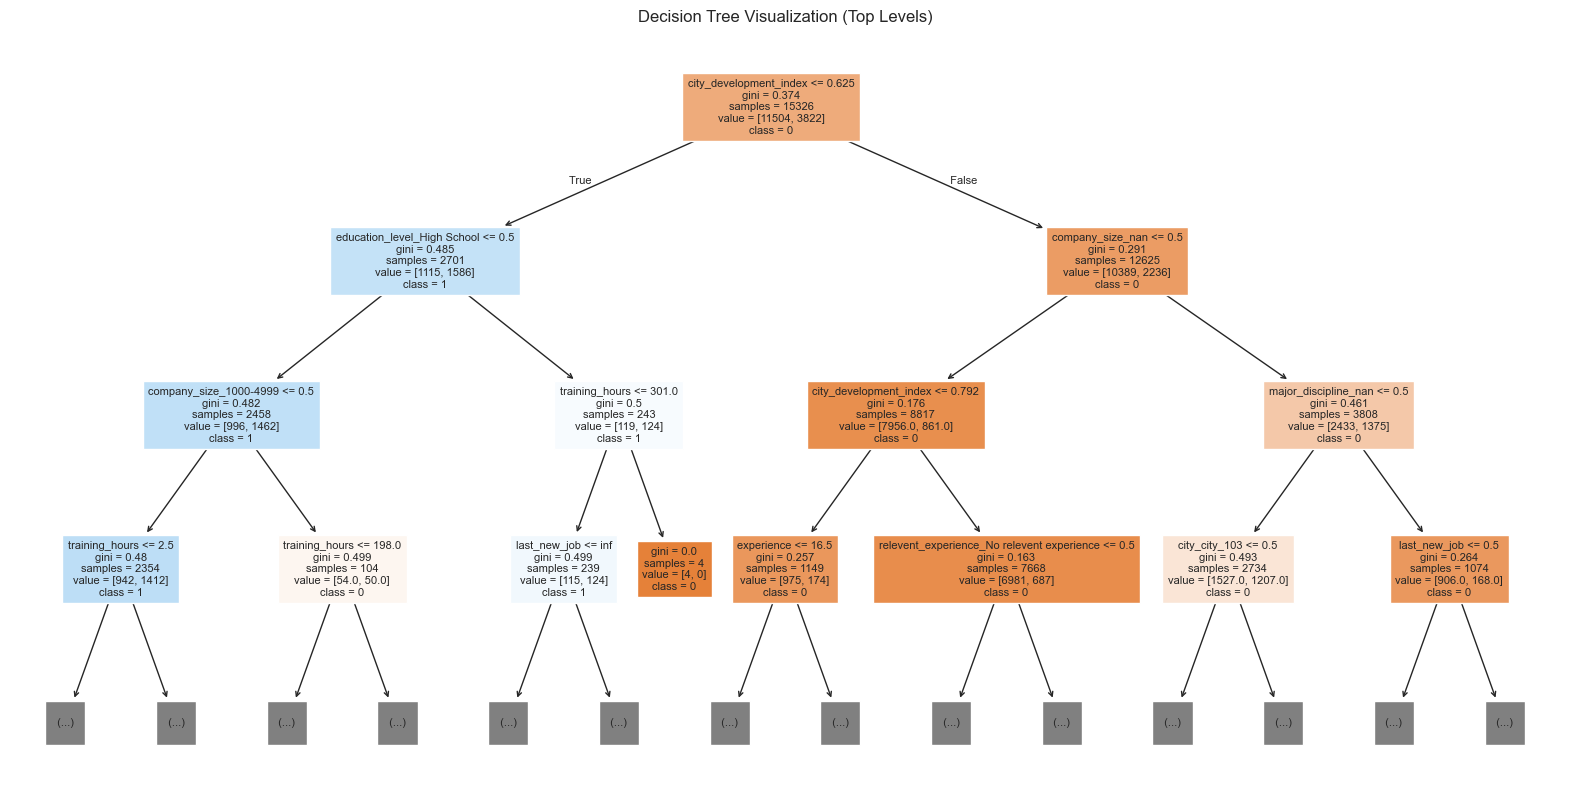

In [22]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()